# Part 5: Clustering With PCA

## Overview
In this notebook, we apply Principal Component Analysis (PCA) to our dataset before running the clustering algorithms. Dimensionality reduction is a powerful technique that helps models like K-Means perform better by removing noise and focusing on the most significant variance in driver profiles.

## Objectives
* Apply PCA to reduce the feature space while retaining the majority of the variance (95%).
* Run K-Means clustering on the principal components.
* Evaluate the distinctiveness and quality of the resulting driver style clusters.

# PCA First

In [2]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import seaborn as sns
from sklearn.metrics import silhouette_score

## Loading the data

In [3]:
# Load data and extract features
df = pd.read_csv("../data/Qualifying_scaled_for_clustering.csv")
identifiers = ['track', 'global_corner_id', 'driver_number']
features = df.drop(columns=identifiers)

## Applying PCA

In [ ]:
# Apply PCA retaining 90% of variance
pca = PCA(n_components=0.90)
pca_data = pca.fit_transform(features)

# Print feature reduction statistics
orig_count = features.shape[1]
reduced_count = pca_data.shape[1]
dropped_count = orig_count - reduced_count

print(f"Original number of features: {orig_count}")
print(f"Features after PCA (components): {reduced_count}")
print(f"Number of features reduced: {dropped_count}")

Original number of features: 12
Features after PCA (components): 8
Number of features reduced: 4


We use PCA to simplify our data by grouping related features into independent components. This fixes the problem of having too many variables, removes statistical noise, and helps the clustering algorithm run faster and more accurately.

## Finding the ideal number of clusters

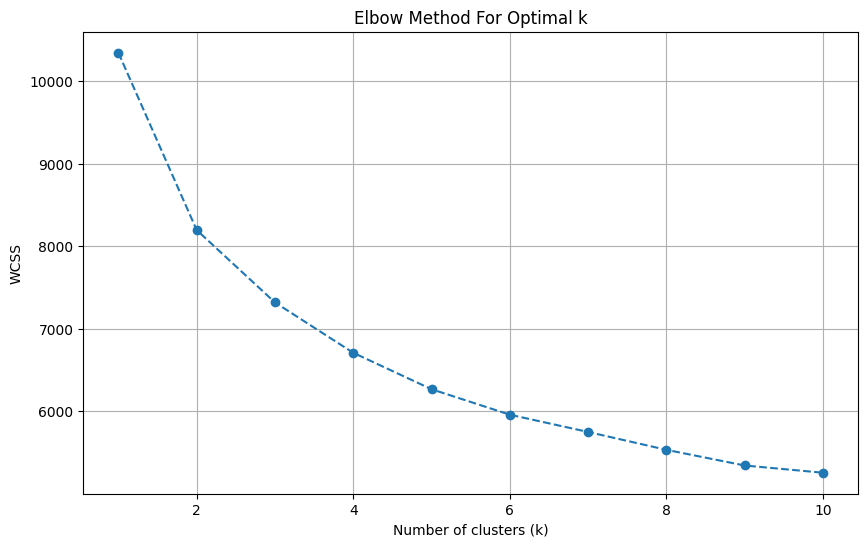

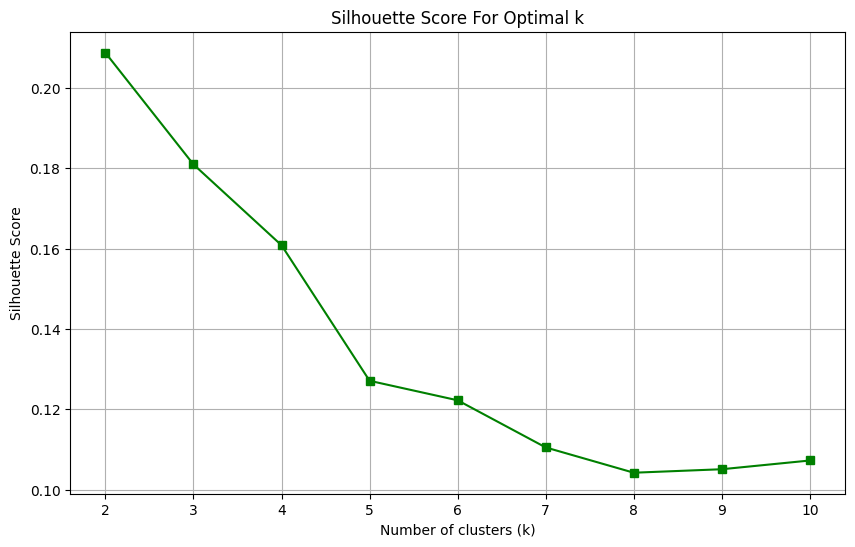

In [5]:
wcss = []
silhouette_scores = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(pca_data)
    wcss.append(kmeans.inertia_)
    
    # Silhouette score is only defined for 2 <= k <= n_samples - 1
    if k > 1:
        score = silhouette_score(pca_data, cluster_labels)
        silhouette_scores.append(score)

# Plot WCSS (Elbow Method)
plt.figure(figsize=(10, 6))
plt.plot(k_values, wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# Plot Silhouette Scores
plt.figure(figsize=(10, 6))
k_values_sil = range(2, 11)
plt.plot(k_values_sil, silhouette_scores, marker='s', linestyle='-', color='green')
plt.title('Silhouette Score For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

The Silhouette score peaks at k=2 (just above 0.2), suggesting it as the mathematical optimum. However, considering the inflection point from the Elbow method, we chose to proceed with k=3 to achieve a more practical and meaningful division of real-world driving styles. The relatively low overall Silhouette score indicates overlapping clusters. This is an expected result, as continuous F1 telemetry data reflects fluid driving behaviors without absolute, sharp boundaries.

## K-Means

In [6]:
# Run K-Means and save labels to the original dataframe
kmeans = KMeans(n_clusters=3, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(pca_data)

## DBSCAN

In [7]:
# Run DBSCAN and save labels to the original dataframe
dbscan = DBSCAN(eps=0.7, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(pca_data)

## Visualization - HEATMAP

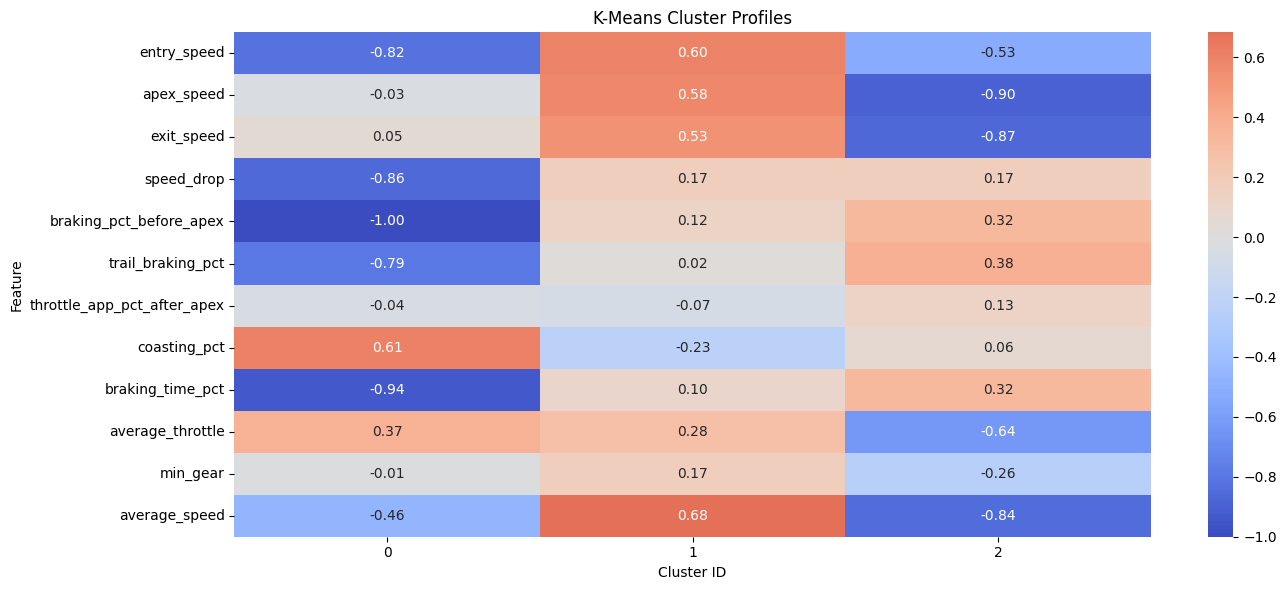

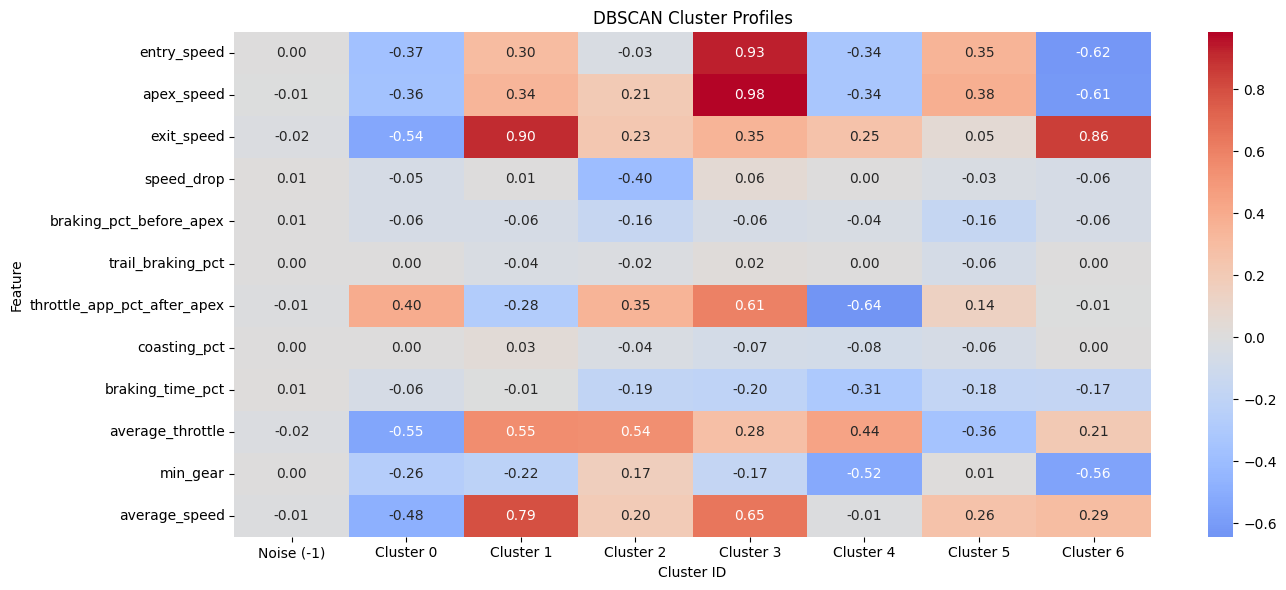

In [8]:

# Calculate feature means for K-Means
kmeans_means = df.groupby('kmeans_cluster')[features.columns].mean()

# Plot K-Means Heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(kmeans_means.T, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('K-Means Cluster Profiles')
plt.xlabel('Cluster ID')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Calculate feature means for DBSCAN
dbscan_means = df.groupby('dbscan_cluster')[features.columns].mean()
dbscan_means.index = [f'Noise (-1)' if c == -1 else f'Cluster {c}' for c in dbscan_means.index]

# Plot DBSCAN Heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(dbscan_means.T, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('DBSCAN Cluster Profiles')
plt.xlabel('Cluster ID')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

We can see that k-means provided clearer and better results, for example, cluster 0 resembles drivers who drive slowly and carefully, with lower speeds overall.

## Visualization - BARPLOT

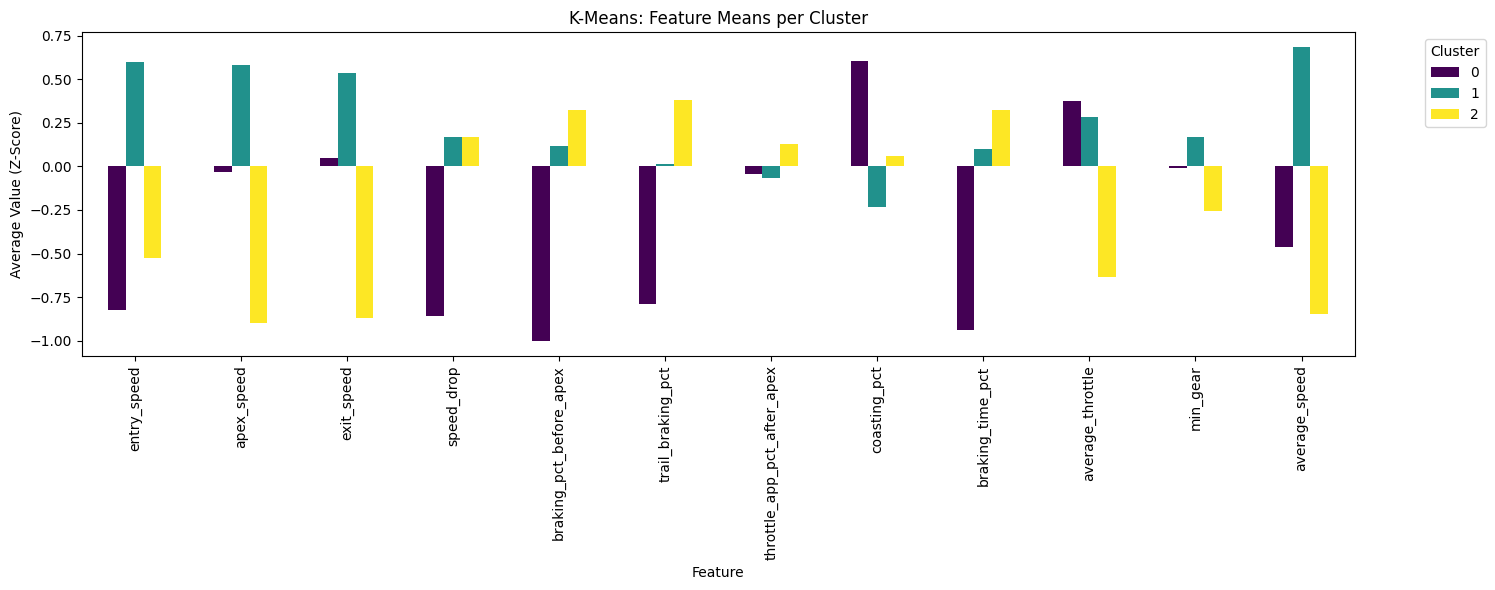

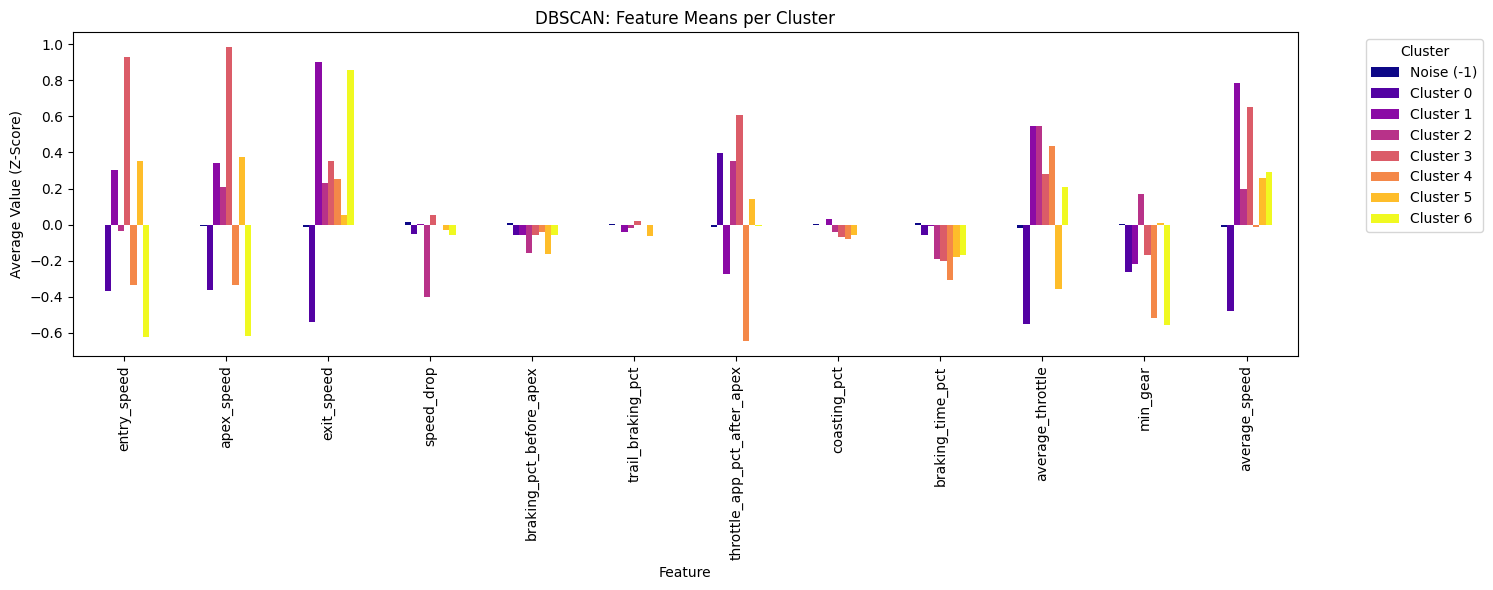

In [9]:
# Plot K-Means Bar Chart
kmeans_means.T.plot(kind='bar', figsize=(15, 6), colormap='viridis')
plt.title('K-Means: Feature Means per Cluster')
plt.xlabel('Feature')
plt.ylabel('Average Value (Z-Score)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot DBSCAN Bar Chart
dbscan_means.T.plot(kind='bar', figsize=(15, 6), colormap='plasma')
plt.title('DBSCAN: Feature Means per Cluster')
plt.xlabel('Feature')
plt.ylabel('Average Value (Z-Score)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

We can use the bar plot of the K-Means to easily understand the characteristics of the different clusters:

Cluster 0: Low speeds, small braking

Cluster 1: High speed, high braking, aggresive driving

Cluster 2: Low entry speeds, almost no breaking, smooth driving

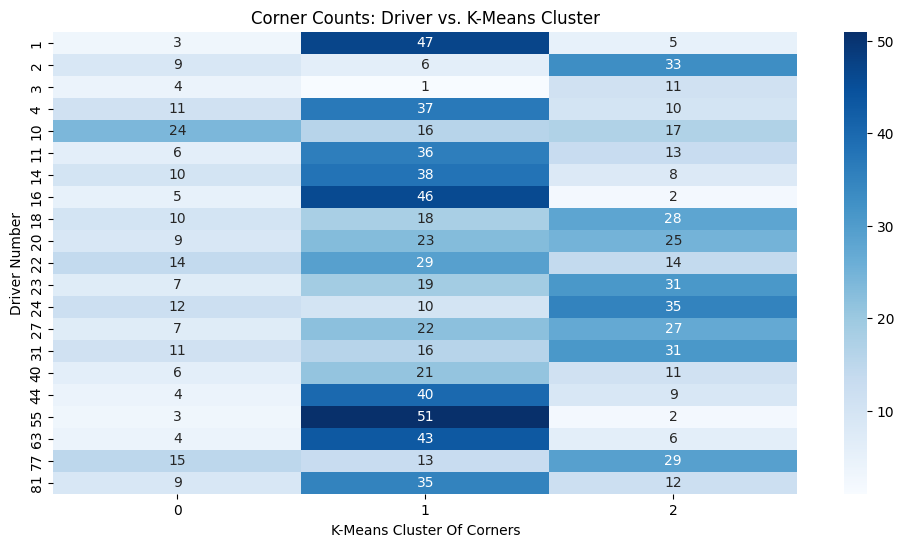

In [10]:
# 1. Macro: Driver vs. K-Means Cluster distribution
driver_cluster_dist = pd.crosstab(df['driver_number'], df['kmeans_cluster'])

plt.figure(figsize=(12, 6))
sns.heatmap(driver_cluster_dist, annot=True, fmt="d", cmap="Blues")
plt.title('Corner Counts: Driver vs. K-Means Cluster')
plt.xlabel('K-Means Cluster Of Corners')
plt.ylabel('Driver Number')
plt.show()

This visualization reveals individual driving habits by highlighting the most common cornering style assigned to each driver.

## Final Clustering

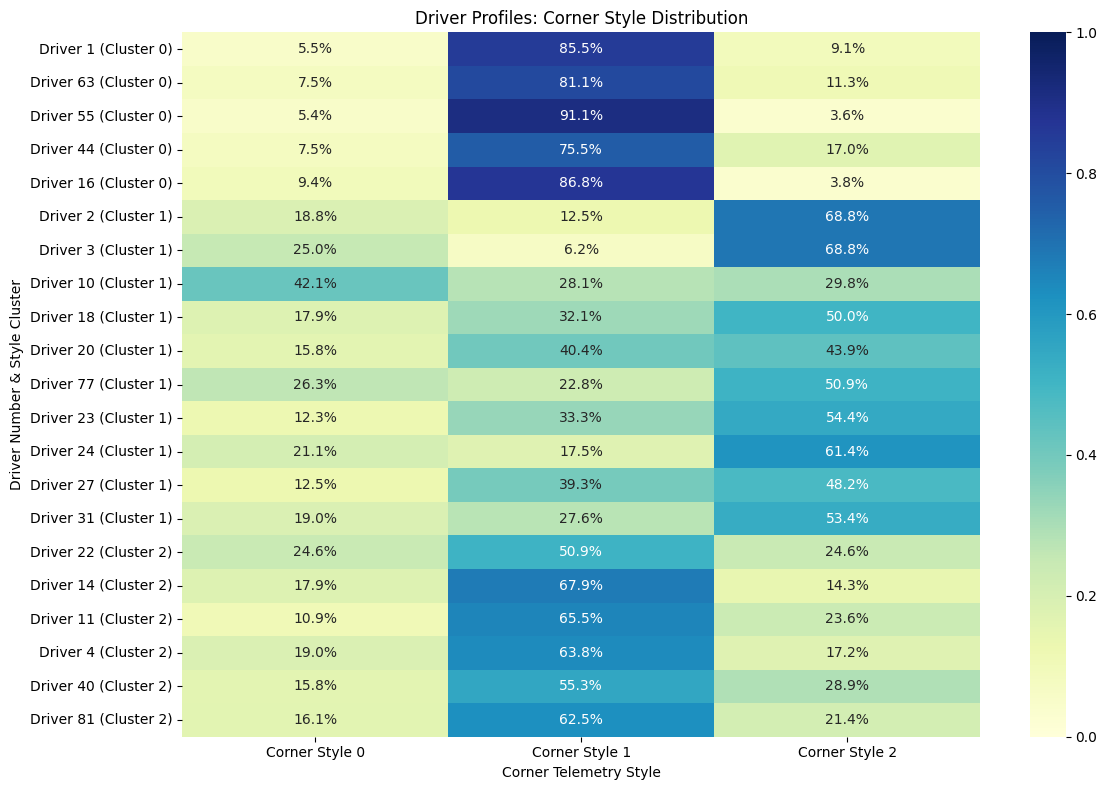

In [11]:
driver_profiles = pd.crosstab(df['driver_number'], df['kmeans_cluster'], normalize='index')
driver_profiles.columns = [f'Corner Style {c}' for c in driver_profiles.columns]

kmeans_drivers = KMeans(n_clusters=3, random_state=42)
driver_profiles['Driver_Style_Cluster'] = kmeans_drivers.fit_predict(driver_profiles)

driver_profiles_sorted = driver_profiles.sort_values('Driver_Style_Cluster')
cluster_labels = driver_profiles_sorted.pop('Driver_Style_Cluster')

plt.figure(figsize=(12, 8))
sns.heatmap(driver_profiles_sorted, annot=True, fmt=".1%", cmap="YlGnBu", vmin=0, vmax=1)

y_labels = [f"Driver {idx} (Cluster {c})" for idx, c in zip(driver_profiles_sorted.index, cluster_labels)]
plt.yticks(ticks=[i + 0.5 for i in range(len(y_labels))], labels=y_labels, rotation=0)

plt.title('Driver Profiles: Corner Style Distribution')
plt.ylabel('Driver Number & Style Cluster')
plt.xlabel('Corner Telemetry Style')
plt.tight_layout()
plt.show()

driver_profiles_sorted['Driver_Style_Cluster'] = cluster_labels

By applying a second clustering step to these corner distributions, we classify drivers into distinct overall 'driving styles'.

## PCA to show driver clusters

In [ ]:
# Reduce driver profiles to 2D for the scatter plot
pca_drivers = PCA(n_components=2, random_state=42)
driver_features = driver_profiles.drop(columns=['Driver_Style_Cluster'])
pca_drivers_2d = pca_drivers.fit_transform(driver_features)

pca_df = pd.DataFrame(data=pca_drivers_2d, columns=['PC1', 'PC2'], index=driver_profiles.index)
pca_df['Driver_Style_Cluster'] = driver_profiles['Driver_Style_Cluster']

# Transform high-dimensional cluster centers into the 2D PCA space
centroids_2d = pca_drivers.transform(kmeans_drivers.cluster_centers_)

# Plot the results
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
sns.scatterplot(x='PC1', y='PC2', hue='Driver_Style_Cluster', data=pca_df, palette='Set1', s=100)

# Plot the centroids as large black 'X' markers
plt.scatter(
    centroids_2d[:, 0], 
    centroids_2d[:, 1], 
    marker='X', 
    s=300, 
    color='black', 
    label='Centroids', 
    zorder=10
)

# Annotate each point with the driver number
for idx, row in pca_df.iterrows():
    plt.annotate(
        str(int(idx)),
        (row['PC1'], row['PC2']),
        textcoords="offset points",
        xytext=(5, 5),
        ha='left',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Driver Style Clusters (2D PCA Projection)')
plt.xlabel('PC1 (Driver Profile Variance)')
plt.ylabel('PC2 (Driver Profile Variance)')

# Update legend to include the centroids
plt.legend(title='Driver Cluster & Centroids')
plt.tight_layout()
plt.show()

ValueError: Shape of passed values is (21, 3), indices imply (21, 2)

The final visualization identifies three distinct groups of drivers, each representing a unique driving style.

Ultimately, using PCA beforehand led to more definitive clusters, effectively highlighting the distinct characteristics of each driving style.